# KNN para Clasificación: ¿Vivienda Cara o Económica?

En la notebook de regresión (`KNN_Regresion_Precio_viviendas.ipynb`) usamos KNN para predecir el **precio exacto** de una vivienda. Acá vamos a usar **el mismo dataset** (mismo código de generación, mismo `seed`), pero para un problema distinto: en vez de predecir un número, vamos a predecir una **categoría**: si una vivienda es **"Cara"** o **"Económica"**, según un umbral de precio.

La idea es mostrar que el mismo problema (precios de viviendas) se puede abordar como regresión o como clasificación, dependiendo de la pregunta que le hagamos a los datos.


## 1. Importar las librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay
)

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 5)


## 2. Crear el dataset (el mismo que en regresión)

Generamos el dataset **exactamente igual** que en la notebook de regresión: mismo `seed`, mismas columnas (`superficie`, `habitaciones`, `antiguedad`) y misma fórmula de precio. Así garantizamos que estamos trabajando sobre el mismo problema, no uno parecido.


In [2]:
np.random.seed(42)
n_samples = 300

superficie = np.random.uniform(50, 250, n_samples)
habitaciones = np.random.randint(1, 6, n_samples)
antiguedad = np.random.uniform(0, 40, n_samples)

# Misma fórmula que en la notebook de regresión: componente determinista + ruido gaussiano
precio = (
    (superficie * 1.5)
    + (habitaciones * 12)
    - (antiguedad * 1.8)
    + np.random.normal(0, 15, n_samples)
    + 40
)

dataset_real = pd.DataFrame({
    'superficie': superficie,
    'habitaciones': habitaciones,
    'antiguedad': antiguedad,
    'precio': precio
})

dataset_real.head()


,superficie,habitaciones,antiguedad,precio
0,124.908024,5,22.763259,262.164922
1,240.142861,4,2.540473,439.930924
2,196.398788,3,1.472875,366.964848
3,169.731697,4,5.354085,345.071453
4,81.203728,5,0.546879,233.429119


## 3. Definir el umbral y crear la categoría "Cara" / "Económica"

Para convertir el precio (un número) en una categoría, definimos un **umbral**. Usamos la **mediana** del precio: las viviendas por encima de la mediana son "Cara", y las de abajo, "Económica". Así las dos clases quedan balanceadas (50%/50%).

En un caso real, el umbral podría ser un valor de negocio fijo (por ejemplo, "más de $250k es cara"), no necesariamente la mediana.


In [3]:
umbral = dataset_real["precio"].median()
print(f"Umbral de precio (mediana): ${umbral:.2f}k USD")

dataset_real["categoria"] = np.where(dataset_real["precio"] > umbral, "Cara", "Economica")

dataset_real["categoria"].value_counts()


Umbral de precio (mediana): $266.67k USD


categoria
Economica    150
Cara         150
Name: count, dtype: int64

In [4]:
dataset_real.head()

,superficie,habitaciones,antiguedad,precio,categoria
0,124.908024,5,22.763259,262.164922,Economica
1,240.142861,4,2.540473,439.930924,Cara
2,196.398788,3,1.472875,366.964848,Cara
3,169.731697,4,5.354085,345.071453,Cara
4,81.203728,5,0.546879,233.429119,Economica


## 4. Explorar los datos (EDA)

Graficamos las viviendas según superficie y antigüedad, coloreadas según su categoría.


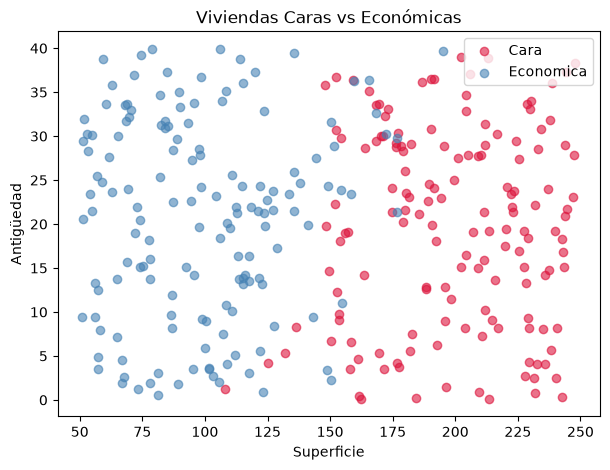

In [5]:
colores = {"Cara": "crimson", "Economica": "steelblue"}

for categoria, color in colores.items():
    subset = dataset_real[dataset_real["categoria"] == categoria]
    plt.scatter(subset["superficie"], subset["antiguedad"],
                label=categoria, color=color, alpha=0.6)

plt.xlabel("Superficie")
plt.ylabel("Antigüedad")
plt.title("Viviendas Caras vs Económicas")
plt.legend()
plt.show()


## 5. Separar features (X) y target (y), y dividir en train/test

Ahora `y` es la columna `categoria` (no el precio). Usamos `stratify=y` para mantener la proporción de viviendas caras y económicas en ambos conjuntos.

El parámetro stratify=y le indica a train_test_split que debe realizar un muestreo estratificado, respetando la proporción de clases del dataset original tanto en el conjunto de entrenamiento (train) como en el de prueba (test).

Solo para Clasificación: No se utiliza en problemas de regresión, ya que las variables continuas no tienen clases discretas sobre las cuales mantener una proporción.


In [6]:
X = dataset_real[["superficie", "habitaciones", "antiguedad"]]
y = dataset_real["categoria"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Filas de entrenamiento: {len(X_train)}")
print(f"Filas de prueba: {len(X_test)}")


Filas de entrenamiento: 240
Filas de prueba: 60


## 6. Escalar los datos

Igual que siempre con KNN: escalamos para que todas las variables pesen parejo en el cálculo de distancia (acá `superficie` va de 50 a 250, y `habitaciones` de 1 a 5).


In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 7. Modelo base con k = 5

Antes de optimizar nada, entrenamos un modelo simple con `k = 5` como punto de partida: para clasificar una vivienda nueva, busca las 5 viviendas más parecidas y vota. Si la mayoría son "Cara", predice "Cara".


In [8]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy con k=5: {acc:.2%}")


Accuracy con k=5: 96.67%


## 8. Evaluar el modelo base

Miramos el classification report y la matriz de confusión, para ver específicamente en qué casos se equivoca: ¿confunde más viviendas caras con económicas, o al revés?


              precision    recall  f1-score   support

        Cara       0.94      1.00      0.97        30
   Economica       1.00      0.93      0.97        30

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60



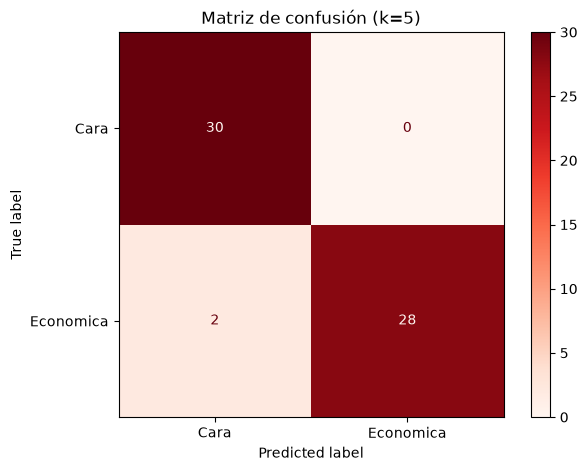

In [9]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap="Reds")
plt.title("Matriz de confusión (k=5)")
plt.show()


## 9. Elegir el mejor k con validación cruzada (GridSearchCV)

En vez de mirar el accuracy en el conjunto de prueba para cada valor de `k` —lo cual "filtra" información del test set hacia la elección del modelo—, usamos `GridSearchCV` con validación cruzada (5-fold), igual que en la notebook de regresión. Esto prueba varias combinaciones de `k`, tipo de peso y métrica de distancia, y se queda con la mejor usando solo el conjunto de entrenamiento.

Recordatorio de la teoría: `k` chico → mayor riesgo de sobreajuste (varianza alta); `k` grande → mayor riesgo de subajuste (sesgo alto). La validación cruzada busca el punto intermedio óptimo sin usar el test set.


In [10]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': range(1, 21),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Mejores hiperparámetros encontrados:\n{grid_search.best_params_}")


Mejores hiperparámetros encontrados:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'}


## 10. Evaluar el modelo final

Evaluamos `best_model` —ya entrenado con el mejor `k` encontrado— sobre el conjunto de prueba, que todavía no participó en ninguna decisión sobre el modelo.


Accuracy (modelo final): 96.67%

              precision    recall  f1-score   support

        Cara       0.94      1.00      0.97        30
   Economica       1.00      0.93      0.97        30

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60



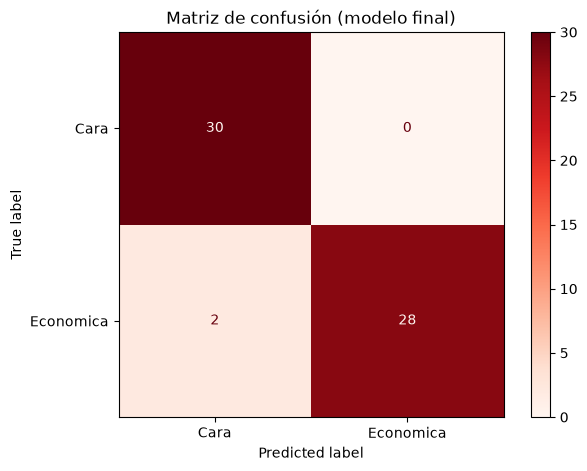

In [11]:
y_pred_final = best_model.predict(X_test)
acc_final = accuracy_score(y_test, y_pred_final)

print(f"Accuracy (modelo final): {acc_final:.2%}")
print()
print(classification_report(y_test, y_pred_final))

cm_final = confusion_matrix(y_test, y_pred_final, labels=best_model.classes_)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=best_model.classes_)
disp_final.plot(cmap="Reds")
plt.title("Matriz de confusión (modelo final)")
plt.show()


## 11. Curva ROC

La curva ROC compara la tasa de verdaderos positivos contra la tasa de falsos positivos para distintos umbrales de decisión. El AUC (área bajo la curva) resume esa curva en un solo número: 1.0 es un clasificador perfecto, 0.5 es equivalente a adivinar al azar.

Usamos la probabilidad de la clase "Cara" que da el modelo **ya entrenado** (`best_model`), buscando explícitamente su posición en `classes_` en vez de asumir cuál columna es.


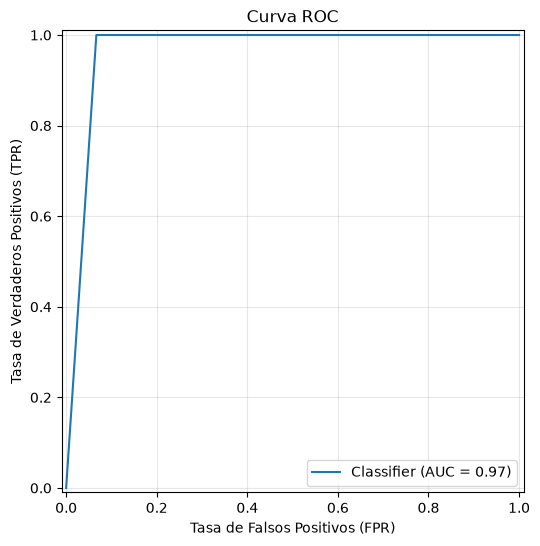

In [12]:
idx_cara = list(best_model.classes_).index("Cara")
y_proba = best_model.predict_proba(X_test)[:, idx_cara]

fig_roc = plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, pos_label="Cara", ax=plt.gca())
plt.title("Curva ROC")
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.grid(alpha=0.3)
plt.show()


## 12. Visualizar la frontera de decisión (con 2 variables)

El modelo final usa 3 variables, así que no podemos graficar su frontera de decisión directamente. Para poder **visualizar** cómo separa el modelo las clases, entrenamos una versión simplificada usando solo `superficie` y `antiguedad`, con el mismo `k` que encontró `GridSearchCV`. Es solo para ilustrar el concepto, no reemplaza al modelo final.


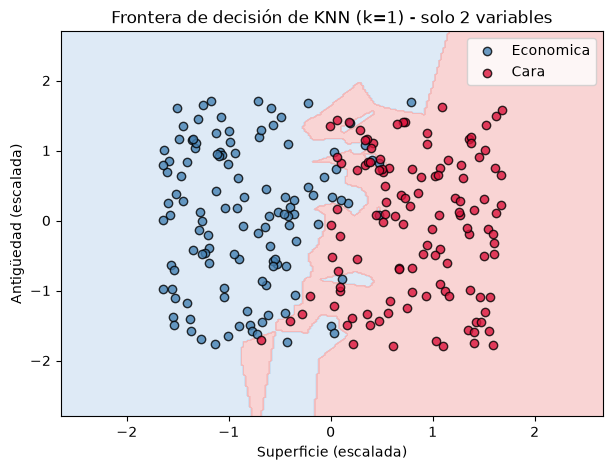

In [13]:
mejor_k = grid_search.best_params_['knn__n_neighbors']

X_vis = dataset_real[["superficie", "antiguedad"]]
y_vis = dataset_real["categoria"]

X_vis_train, X_vis_test, y_vis_train, y_vis_test = train_test_split(
    X_vis, y_vis, test_size=0.2, random_state=42, stratify=y_vis
)

scaler_vis = StandardScaler()
X_vis_train_scaled = scaler_vis.fit_transform(X_vis_train)

knn_vis = KNeighborsClassifier(n_neighbors=mejor_k)
knn_vis.fit(X_vis_train_scaled, y_vis_train)

h = 0.02
x_min, x_max = X_vis_train_scaled[:, 0].min() - 1, X_vis_train_scaled[:, 0].max() + 1
y_min, y_max = X_vis_train_scaled[:, 1].min() - 1, X_vis_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z == "Cara").astype(int).reshape(xx.shape)

cmap_fondo = ListedColormap(["#c9dcf0", "#f5b8b8"])
cmap_puntos = ListedColormap(["steelblue", "crimson"])

plt.contourf(xx, yy, Z, cmap=cmap_fondo, alpha=0.6)

for i, categoria in enumerate(["Economica", "Cara"]):
    mask = (y_vis_train.values == categoria)
    plt.scatter(X_vis_train_scaled[mask, 0], X_vis_train_scaled[mask, 1],
                label=categoria, color=cmap_puntos(i), edgecolor="k", alpha=0.8)

plt.xlabel("Superficie (escalada)")
plt.ylabel("Antigüedad (escalada)")
plt.title(f"Frontera de decisión de KNN (k={mejor_k}) - solo 2 variables")
plt.legend()
plt.show()


## 13. Predecir una vivienda nueva

Probemos con la misma vivienda del ejemplo manual de regresión: 150 m² de superficie, 3 habitaciones, 9 años de antigüedad. El modelo nos dice si entra en la categoría "Cara" o "Económica", en vez de darnos un precio exacto.


In [14]:
vivienda_nueva = pd.DataFrame({
    "superficie": [150],
    "habitaciones": [3],
    "antiguedad": [9]
})

prediccion = best_model.predict(vivienda_nueva)
probabilidades = best_model.predict_proba(vivienda_nueva)

print(f"Predicción: {prediccion[0]}")
print(f"Probabilidades ({best_model.classes_}): {probabilidades[0]}")


Predicción: Cara
Probabilidades (['Cara' 'Economica']): [1. 0.]


## 14. Conclusión

- Usamos el **mismo dataset** que en la notebook de regresión (mismo código, mismo `seed`), cambiando solo la pregunta: en vez de "¿cuánto vale?", preguntamos "¿es cara o económica?".
- Para pasar de un problema de regresión a uno de clasificación, definimos un **umbral** sobre la variable numérica (acá, la mediana del precio).
- Elegimos `k` con `GridSearchCV` y validación cruzada, igual que en la notebook de regresión, evitando usar el conjunto de prueba para tomar decisiones sobre el modelo.
- Evaluamos con accuracy, matriz de confusión y curva ROC/AUC — las métricas propias de un problema de clasificación, en contraste con MAE/RMSE/R² que usamos para regresión.
